Implement a prediction model using Deep Learning pre trained models on an application dataset (pet breed recognition).

Operations to be performed:
1. Import the required Python libraries and dataset.
2. Normalizing dataset.
3. Identifying the pretrained model to be used.
4. As per the need, fine tune the pretrained architecture.
5. Train the model with training dataset.
6. Predict the model with testing dataset.
7. Model performance visualization in terms of accuracy and loss.

In [ ]:
# 1) Import required Python libraries and dataset
import numpy as np
import tensorflow as tf
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D, Input
from tensorflow.keras.optimizers import Adam

print('TensorFlow version:', tf.__version__)

# Load an application dataset: Oxford-IIIT Pet (pet breed classification)
(train_raw, val_raw, test_raw), ds_info = tfds.load(
    'oxford_iiit_pet:3.*.*',
    split=['train[:80%]', 'train[80%:]', 'test'],
    as_supervised=True,
    with_info=True
)

class_names = ds_info.features['label'].names
num_classes = len(class_names)
print('Number of classes:', num_classes)
print('Example classes:', class_names[:5])

c:\Users\user\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


TensorFlow version: 2.16.1
Train shape: (50000, 32, 32, 3) (50000, 1)
Test shape : (10000, 32, 32, 3) (10000, 1)


In [ ]:
# 2) Normalize dataset and prepare labels
img_size = 128
batch_size = 64

def preprocess(image, label):
    image = tf.image.resize(image, (img_size, img_size))
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

def make_dataset(ds, training=False):
    ds = ds.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
    if training:
        ds = ds.shuffle(2000)
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds

# Use smaller subsets for faster experimentation
train_raw_small = train_raw.take(2400)
val_raw_small = val_raw.take(600)
test_raw_small = test_raw.take(1200)

train_ds = make_dataset(train_raw_small, training=True)
val_ds = make_dataset(val_raw_small, training=False)
test_ds = make_dataset(test_raw_small, training=False)

print('Datasets are ready.')

x_train_small: (16000, 32, 32, 3)
x_val       : (4000, 32, 32, 3)
x_test      : (10000, 32, 32, 3)


In [ ]:
# Input pipeline is prepared in the previous cell at 128x128 for MobileNetV2
print('Image size:', img_size)
print('Batch size:', batch_size)

Datasets are ready.


In [ ]:
# 3) Identify pretrained model to be used
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_tensor=Input(shape=(img_size, img_size, 3))
)

# Freeze base model initially for transfer learning
base_model.trainable = False

# Build classification head
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.2)(x)
outputs = Dense(num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=outputs)
model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

C:\Users\user\AppData\Local\Temp\ipykernel_18936\4023591844.py:2: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 96, 96, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 48, 48,    │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 48, 48,    │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 48, 48,    │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 48, 48,    │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 48, 48,    │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 48, 48,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 48, 48,    │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 48, 48,    │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 48, 48,    │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 48, 48,    │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 48, 48,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 49, 49,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 24, 24,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 24, 24,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 24, 24,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 24, 24,    │      2,304 │ block_1_depthwis

 Total params: 2,423,242 (9.24 MB)

 Trainable params: 165,258 (645.54 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
# 4) Fine-tune pretrained architecture (light fine-tuning for speed)
base_model.trainable = True
for layer in base_model.layers[:-20]:
    layer.trainable = False

model.compile(
    optimizer=Adam(learning_rate=5e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print('Trainable layers:', sum([int(l.trainable) for l in model.layers]))

Trainable layers: 14


In [ ]:
# 5) Train the model with training dataset
epochs = 3

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs,
    verbose=1
)

Epoch 1/3
125/125 ━━━━━━━━━━━━━━━━━━━━ 61s 440ms/step - accuracy: 0.4526 - loss: 1.6170 - val_accuracy: 0.3485 - val_loss: 2.1451
Epoch 2/3
125/125 ━━━━━━━━━━━━━━━━━━━━ 57s 453ms/step - accuracy: 0.6549 - loss: 1.0256 - val_accuracy: 0.3755 - val_loss: 2.1098
Epoch 3/3
125/125 ━━━━━━━━━━━━━━━━━━━━ 90s 724ms/step - accuracy: 0.7093 - loss: 0.8540 - val_accuracy: 0.3938 - val_loss: 2.3103


In [ ]:
# 6) Predict the model with testing dataset
test_loss, test_acc = model.evaluate(test_ds, verbose=1)
print(f'Test Loss: {test_loss:.4f}')
print(f'Test Accuracy: {test_acc:.4f}')

pred_probs = model.predict(test_ds, verbose=1)
pred_classes = np.argmax(pred_probs, axis=1)
true_classes = np.concatenate([y.numpy() for _, y in test_ds], axis=0)

# Display a few sample predictions
sample_n = 10
for i in range(sample_n):
    print(f'Sample {i+1}: True={class_names[int(true_classes[i])]}, Pred={class_names[int(pred_classes[i])]}')

79/79 ━━━━━━━━━━━━━━━━━━━━ 45s 566ms/step - accuracy: 0.3988 - loss: 2.2999
Test Loss: 2.2999
Test Accuracy: 0.3988
79/79 ━━━━━━━━━━━━━━━━━━━━ 62s 665ms/step
Sample 1: True=cat, Pred=automobile
Sample 2: True=ship, Pred=ship
Sample 3: True=ship, Pred=ship
Sample 4: True=airplane, Pred=ship
Sample 5: True=frog, Pred=airplane
Sample 6: True=frog, Pred=airplane
Sample 7: True=automobile, Pred=automobile
Sample 8: True=frog, Pred=bird
Sample 9: True=cat, Pred=bird
Sample 10: True=automobile, Pred=automobile


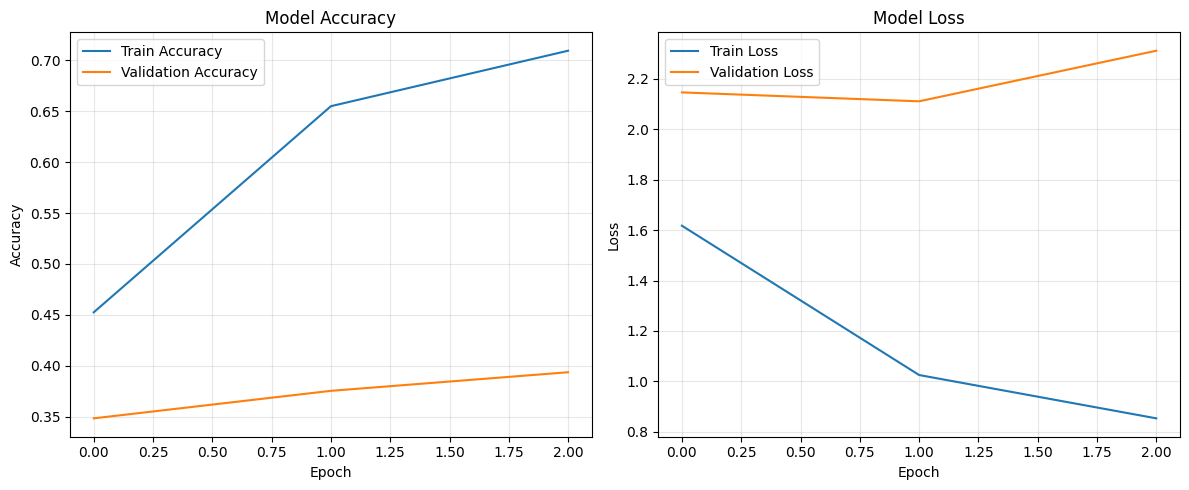

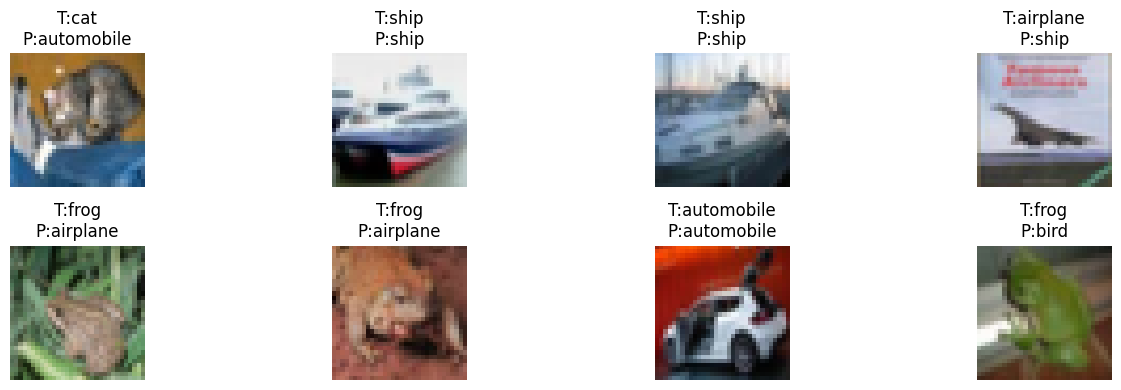

In [ ]:
# 7) Model performance visualization (accuracy and loss)
plt.figure(figsize=(12, 5))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Visualize a few test predictions
sample_images = []
sample_labels = []
for image_batch, label_batch in test_ds.unbatch().batch(8).take(1):
    sample_images = image_batch.numpy()
    sample_labels = label_batch.numpy()

sample_preds = np.argmax(model.predict(sample_images, verbose=0), axis=1)

plt.figure(figsize=(14, 4))
for i in range(8):
    plt.subplot(2, 4, i + 1)
    plt.imshow(sample_images[i])
    plt.title(f'T:{class_names[int(sample_labels[i])]}\nP:{class_names[int(sample_preds[i])]}')
    plt.axis('off')
plt.tight_layout()
plt.show()